# **DecodeLabs Project 3: Random Forest for Classifying Digits**

**Importing Relevant Libraries**

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix

**Data Sourcing**

In [2]:
digits = load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

**Data Visualization**

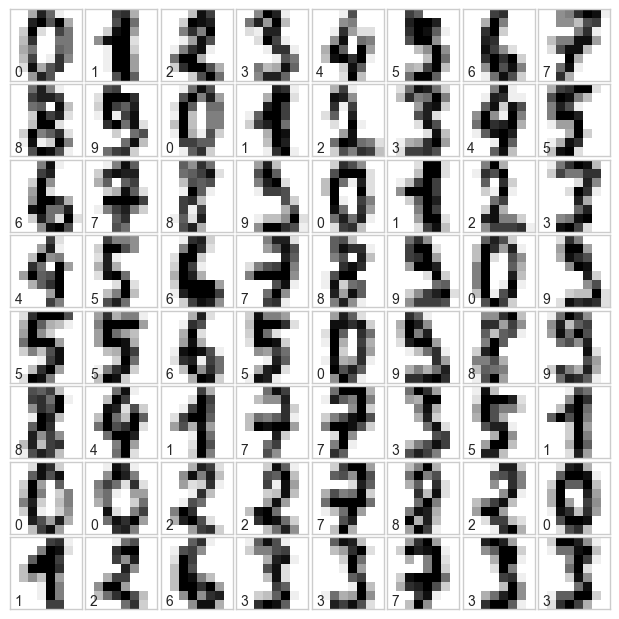

In [3]:
# Set up the figure
fig = plt.figure(figsize=(6, 6)) 
fig.subplots_adjust(left=0, right=1, bottom=0, top=1,
 hspace=0.05, wspace=0.05)

for i in range(64):
    ax = fig.add_subplot(8, 8, i + 1, xticks = [], yticks = [])
    ax.imshow(digits.images[i], cmap = plt.cm.binary, interpolation = 'nearest')

    ax.text(0, 7, str(digits.target[i]))

In [4]:
digits.target

array([0, 1, 2, ..., 8, 9, 8], shape=(1797,))

**Splitting our Data**

In [5]:
Xtrain, Xtest, ytrain, ytest = train_test_split(digits.data, digits.target, random_state = 0)

**Building our Random Forest Model**

In [6]:
model = RandomForestClassifier(1000).fit(Xtrain, ytrain)
ypred = model.predict(Xtest)

**Classification Report**

In [7]:
print(metrics.classification_report(ytest, ypred))


              precision    recall  f1-score   support

           0       0.97      1.00      0.99        37
           1       0.96      1.00      0.98        43
           2       1.00      0.95      0.98        44
           3       0.98      0.98      0.98        45
           4       1.00      0.97      0.99        38
           5       0.98      0.98      0.98        48
           6       1.00      1.00      1.00        52
           7       0.96      1.00      0.98        48
           8       0.98      0.94      0.96        48
           9       0.98      0.98      0.98        47

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



**Heatmap of our Model's Performance**

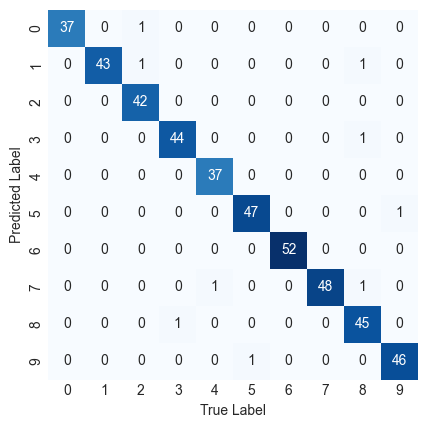

In [8]:
mat = confusion_matrix(ytest, ypred)
import seaborn as sns
sns.heatmap(mat.T, square=True, annot = True, fmt = 'd', cbar = False, cmap = 'Blues')
plt.xlabel('True Label')
plt.ylabel('Predicted Label');